In [1]:
]activate ../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`


In [2]:
using Revise
includet("./base.jl")
includet("./plotting_extras.jl")

┌ Warning: Circular dependency detected.
│ Precompilation will be skipped for dependencies in this cycle:
│  ┌ Symbolics → SymbolicsForwardDiffExt
│  └─ Symbolics → SymbolicsPreallocationToolsExt
│ Precompilation will also be skipped for the following, which depend on the above cycle:
│   SSMC
│   MLSolver
└ @ Pkg.API.Precompilation ~/.julia/juliaup/julia-1.10.10+0.x64.linux.gnu/share/julia/stdlib/v1.10/Pkg/src/precompilation.jl:583
Precompiling packages...
  14230.1 ms  ✓ SSMCMain
  1 dependency successfully precompiled in 18 seconds. 544 already precompiled. 4 skipped due to circular dependency.


In [3]:
using CairoMakie
using GLMakie
CairoMakie.activate!()

# Testing v1

In [4]:
K = 10.
l = 1.
p = 0.01

N = 20
M = N

DN = 1e-6

rsg = get_si_sampler_for_paper(K, l, DN;
    N, M,
    DR=p,
);

In [5]:
gen_ps = rsg()

BSMMiCRMParams{Nothing, Nothing, Nothing, Float64}(BMMiCRMParams{Nothing, Float64}([1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [0.9976127098036836, 1.0026341132935728, 1.0011370715044112, 0.9972030310824143, 0.9984843933424802, 0.995703679905404, 1.0031854157427136, 1.0022014366614729, 1.001533021555609, 1.0016108771410592, 1.0010620867081528, 0.998782691363358, 1.0043220961150003, 1.0005480595783958, 0.9984764852056536, 1.0025581329106967, 0.9974894394420607, 0.9989610820134485, 1.0025356071216807, 0.9984520554064297], [0.0, 0.0, 0.0, 10.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0

In [8]:
T = 1e8
tol = 1e-9

ode_u0 = [fill(1., N); fill(0., M)]

ode_p = make_mmicrm_problem(gen_ps.mmicrm_params, copy(ode_u0), T)
ode_s = solve(ode_p, TRBDF2();
    maxiters=100000,
    callback=CallbackSet(make_timer_callback(10), PositiveDomain(copy(ode_u0))),
);
ode_fs = ode_s.u[end]
@show mmicrmmaxresid(ode_s) sum(ode_fs[1:N]) count(>(1e-9), ode_fs[1:N]);

mmicrmmaxresid(ode_s) = 4.446443213623752e-14
sum(ode_fs[1:N]) = 2.1341797658571413
count((>)(1.0e-9), ode_fs[1:N]) = 3


In [9]:
L = 5
sN = 1000
dx = L / sN
sp_epsilon = 1e-3

pde_u0 = expand_u0_to_size((sN,), ode_fs)
pde_u0 = perturb_u0_uniform(N, M, pde_u0, sp_epsilon)
clamp!(pde_u0, 0., Inf);

In [56]:
pde_ps = BSMMiCRMParams(
    gen_ps.mmicrm_params,
    gen_ps.Ds,
    CartesianSpace{1,Tuple{Periodic}}(SA[dx]),
    nthreads()
)
pde_p = make_smmicrm_problem(pde_ps, pde_u0, T; jac_type=:sparse);

pde_s_t, pde_s_u, scb = make_stepped_saver_callback(pde_u0, 10)
pde_s = solve(pde_p, TRBDF2();
    dense=false,
    abstol=tol,
    reltol=tol,
    callback=CallbackSet(make_timer_callback(15), PositiveDomain(copy(pde_u0); save=false), scb),
);
smmicrmmaxresid(pde_s)

0.0021966987058268206

In [57]:
pde_s_t

9-element Vector{Float64}:
  5.941035016265186e-9
  0.0013088189917240842
  0.03026183851507283
  0.27086125849793047
  0.9735623788044931
  2.232700735118563
  4.438113385419751
  7.438677851302863
 11.034300611623047

In [50]:
pde_s.t

10-element Vector{Float64}:
 0.0
 5.941035016265186e-9
 6.535138517891704e-8
 6.594548868054356e-7
 6.600489903070621e-6
 2.148798053469435e-5
 4.402103604359816e-5
 0.00011404544516587284
 0.00021392030639480965
 0.0004936292112377275

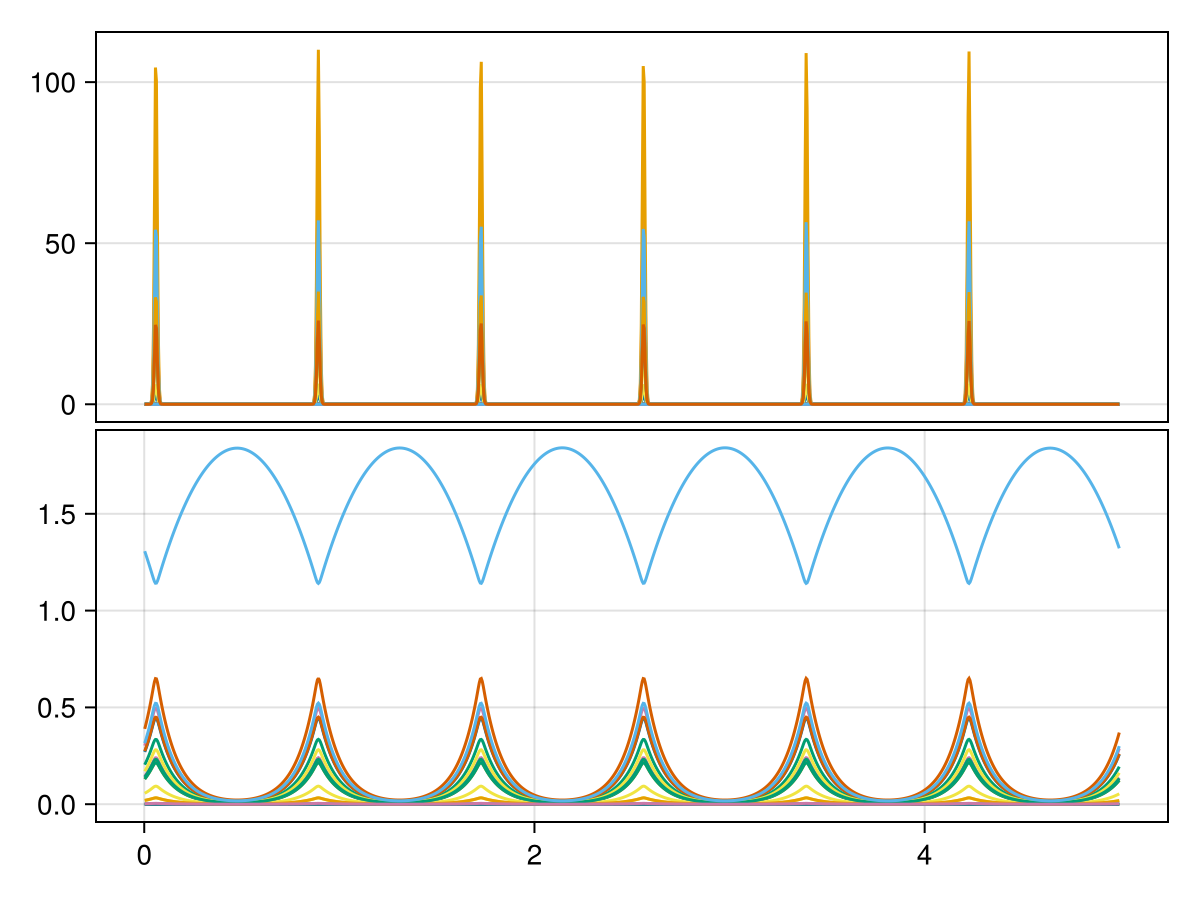

In [10]:
plot_spatial_fs(pde_s.u[end], N, sN, dx)

In [11]:
f = plot_1dsmmicrm_sol_interactive(pde_s)
display(GLMakie.Screen(), f)

GLMakie.Screen(...)

In [14]:
pde_means = map(pde_s.u) do u
    reshape(mean(u; dims=2), N+M)
end;

In [17]:
length(pde_s.t)

40027

In [25]:
jldsave("./testing_pde_s2_p0.01_increase.jld2"; pde_s)

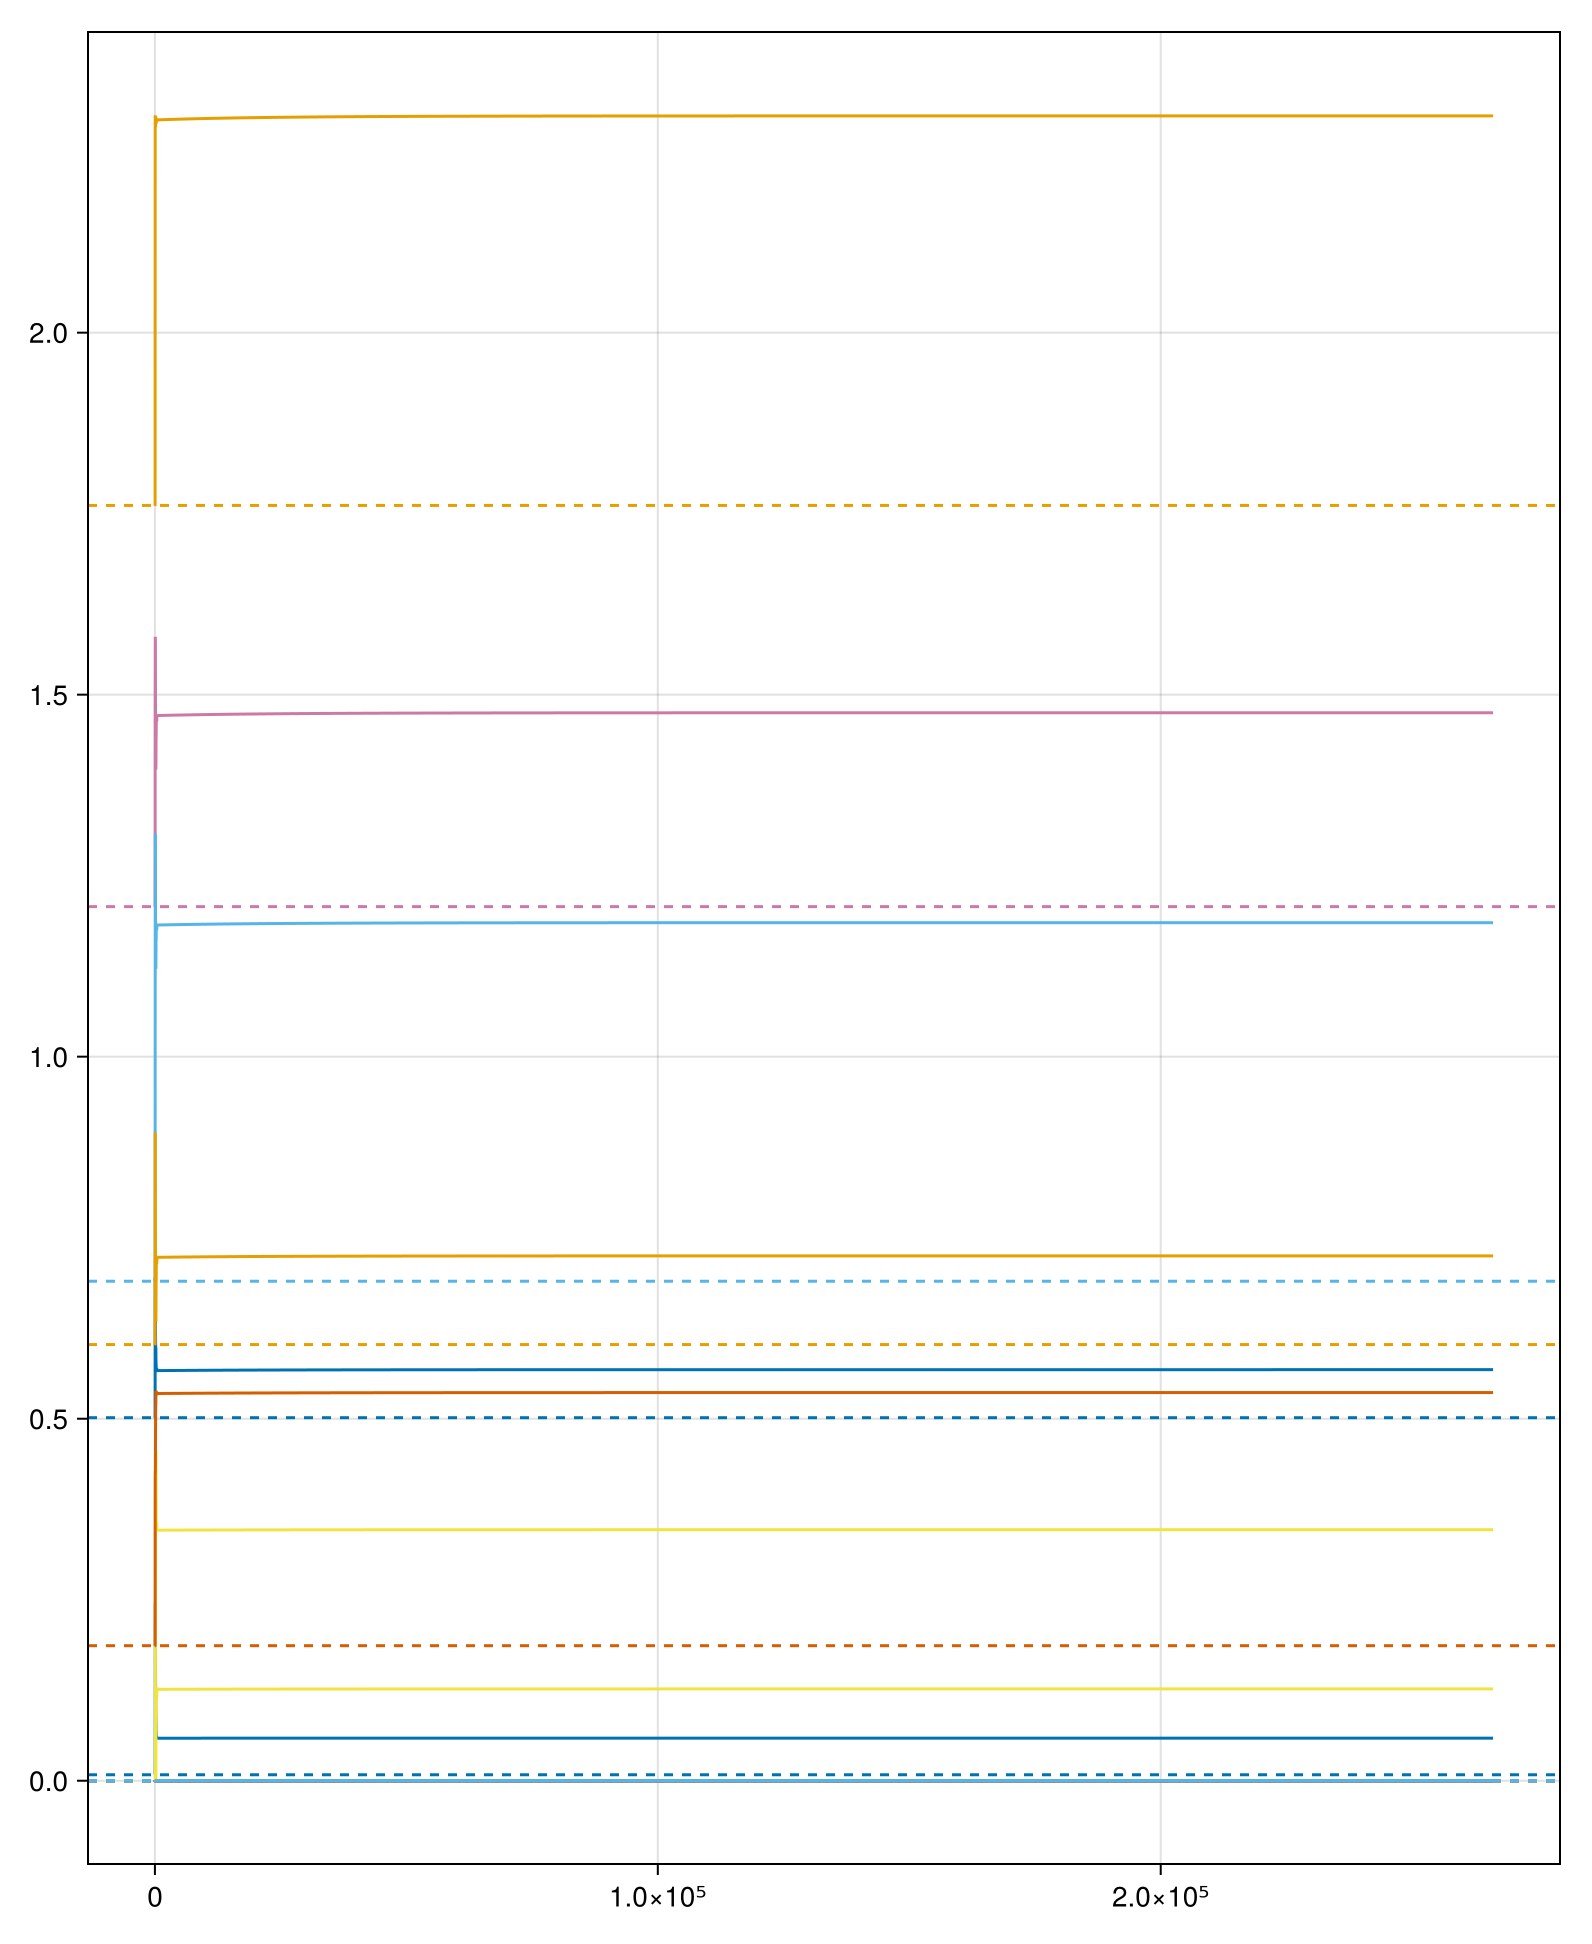

In [23]:
fig = Figure()
ax = Axis(fig[1,1])

# iis = 1:100:length(pde_s.t)
iis = 1:100:length(pde_s.t)

for i in 1:N
    lines!(ax, pde_s.t[iis], getindex.(pde_means, i)[iis])
    hlines!(ax, [ode_fs[i]];
        linestyle=:dash
    )
end

display(GLMakie.Screen(), fig)

fig